In [8]:
import sys
from pathlib import Path
from functools import partial

import numpy as np
import torch
import matplotlib.pyplot as plt

# Project imports
sys.path.insert(0, str(Path("..").resolve()))
import config
from pipeline.dataset import load_dataset
from pipeline.routes import holds_to_array
from evaluation.baselines import hanging_baseline_predictions, compute_rl_bone_lengths
from evaluation.metrics import build_pose_bank, pose_bank_summary, nearest_neighbor_pose_distance, summarize_nn_distances
from evaluation.visualize import plot_nn_pose_comparison, _draw_skeleton_mpl
from models.world_model import (
    StructuredPoseTransformer, compute_reference_bone_lengths,
    resolve_hold_sequence_and_targets,
)
from models.rl_baseline import prepare_routes_for_rl, ClimbingEnv, rollout_episode
from scripts.run_visualize import load_model, hold_orders_applied_for
from scripts.train_rl import PolicyNetwork, ValueNetwork
from IPython.display import display, Image



# === FILL THESE IN ===
WM_CHECKPOINT = Path("../data/checkpoints/best_hold_filtered.pt")
RL_CHECKPOINT = Path("../data/FIRST_RUN/FIRST_RUN_RL_CHECKPOINTS/Static_controller/step_2752512.pt")
ROUTE_INDEX = 11          # index into test set — browse below to pick
RL_STOCHASTIC_ATTEMPTS = 250

{'bank_size': 32292, 'raw_frame_count': 52252, 'compression_ratio': '1.6x'}


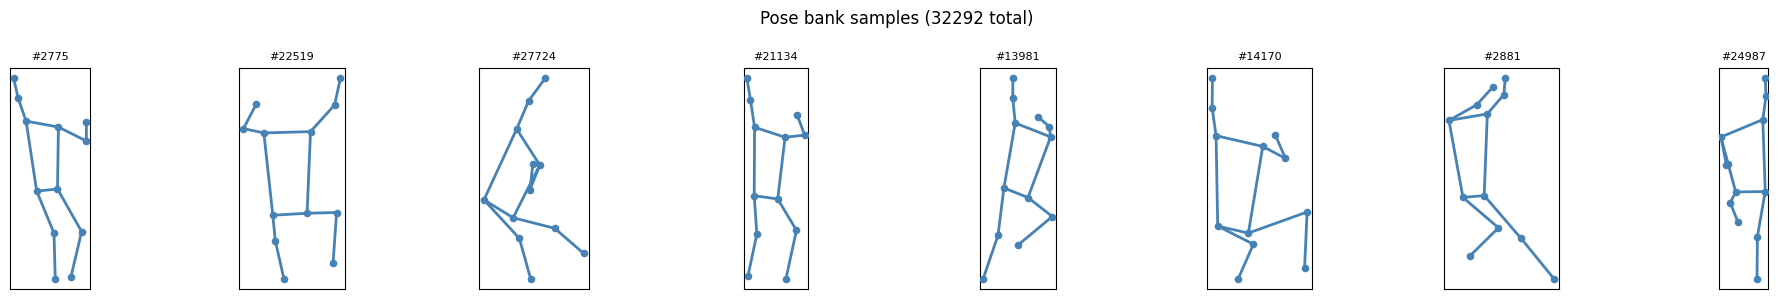

In [9]:
data = load_dataset(Path("../data/dataset.npz"))
bank, bank_norm = build_pose_bank(data["train_sequences"])
print(pose_bank_summary(bank, data["train_sequences"]))

# Preview: 8 random bank samples
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
rng = np.random.default_rng(42)
sample_idxs = rng.choice(len(bank), 8, replace=False)
for ax, idx in zip(axes, sample_idxs):
    _draw_skeleton_mpl(ax, bank[idx], color="steelblue")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{idx}", fontsize=8)
fig.suptitle(f"Pose bank samples ({len(bank)} total)", fontsize=12)
plt.tight_layout()

In [10]:
for i, stem in enumerate(data["test_stems"]):
    seq_len = len(data["test_sequences"][i])
    n_holds = sum(1 for h in data["test_route_holds"][i] if h.get("role_id", 0) > 0)
    print(f"  [{i}] {stem:30s}  {seq_len:>5} frames, {n_holds} holds")

  [0] centurion                         505 frames, 13 holds
  [1] contact_wombat                    423 frames, 8 holds
  [2] pretty_legit_4a                   674 frames, 16 holds
  [3] sad                               755 frames, 13 holds
  [4] finally_an_actual_v0              497 frames, 12 holds
  [5] sharp_pines                       401 frames, 10 holds
  [6] soft                              498 frames, 14 holds
  [7] cranky                            616 frames, 11 holds
  [8] little_avoidance_therapy         1021 frames, 14 holds
  [9] chicken_nuggies                   549 frames, 9 holds
  [10] shrimp_burrito                    717 frames, 12 holds
  [11] static_controller                1003 frames, 17 holds
  [12] toodles                           672 frames, 11 holds
  [13] diagonal_traverse_warm_up         680 frames, 13 holds
  [14] cchhhhooooccccoooolllaaatteee     771 frames, 12 holds
  [15] chalk_the_chalk                   805 frames, 15 holds
  [16] easy_pinch   

In [4]:
ri = ROUTE_INDEX
stem = data["test_stems"][ri]
gt_seq = data["test_sequences"][ri]        # (T, 17, 2)
gt_frames = list(gt_seq)
route_holds = data["test_route_holds"][ri]
scores = data["test_scores"][ri]

idx = config.CLIMBING_KEYPOINT_INDICES
bl = compute_rl_bone_lengths(data["train_sequences"])
ref_bones = compute_reference_bone_lengths(data["train_sequences"])
device = config.get_device()

# --- Hanging baseline ---
hang_preds, _, hang_init = hanging_baseline_predictions(
    gt_frames, route_holds, stem, bone_lengths=bl, verbose=True
)
hanging_poses = [hang_init] + hang_preds  # list of (12, 2)
print(f"Hanging: {len(hanging_poses)} frames")

# --- World model ---
model = load_model(WM_CHECKPOINT, device)
is_structured = isinstance(model, StructuredPoseTransformer)
hold_positions, hold_roles = holds_to_array(route_holds, normalize=True)

if is_structured:
    from evaluation.visualize import autoregressive_rollout_structured
    gt_filtered = gt_seq[:, idx, :]
    apply_ho = hold_orders_applied_for(WM_CHECKPOINT)
    hold_seq, _ = resolve_hold_sequence_and_targets(
        gt_filtered, route_holds, stem if apply_ho else None
    )
    wm_poses, _ = autoregressive_rollout_structured(
        model, gt_seq[:config.CONTEXT_WINDOW], len(gt_seq),
        hold_positions, hold_roles, hold_seq,
        device, max_bone_lengths=ref_bones,
    )
else:
    from evaluation.visualize import autoregressive_rollout
    wm_poses = autoregressive_rollout(
        model, gt_seq[:config.CONTEXT_WINDOW], len(gt_seq),
        hold_positions, hold_roles, device,
        max_bone_lengths=ref_bones,
    )
print(f"World model: {len(wm_poses)} frames")

# --- RL agent (best of N stochastic) ---
routes, bone_lengths_rl = prepare_routes_for_rl(data)
env = ClimbingEnv(routes, bone_lengths_rl)
obs_dim = env.observation_space.shape[0]
policy = PolicyNetwork(obs_dim).to(device)
rl_ckpt = torch.load(RL_CHECKPOINT, weights_only=False)
policy.load_state_dict(rl_ckpt["policy"])
policy.eval()

# Find route index in RL env's route list
rl_route_idx = next(
    i for i, r in enumerate(routes) if r.stem == stem
)

def stochastic_action_fn(env, step):
    obs = env._build_obs()
    obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
    with torch.no_grad():
        cont_a, disc_a, _ = policy.sample(obs_t)
    return {
        "joint_deltas": cont_a.cpu().numpy(),
        "grab_release": disc_a.cpu().numpy().astype(np.int32),
    }

best_rl, best_hv = None, -1
for a in range(RL_STOCHASTIC_ATTEMPTS):
    ep = rollout_episode(env, stochastic_action_fn, route_index=rl_route_idx,
                         max_steps=config.RL_STEP_LIMIT)
    hv = ep["info"]["holds_visited"]
    print(f"  RL attempt {a+1}/{RL_STOCHASTIC_ATTEMPTS}: "
          f"{hv}/{ep['info']['total_holds']} holds, {ep['outcome']}")
    if hv > best_hv:
        best_hv = hv
        best_rl = ep

rl_poses = best_rl["poses"]  # list of (12, 2)
print(f"RL: {len(rl_poses)} frames (best: {best_hv} holds visited)")

  Hanging baseline: 7 transitions over 505 frames
Hanging: 505 frames
Loaded structured checkpoint: epoch 36, val_loss 11.374136960506439
World model: 870 frames
  RL attempt 1/250: 0/7 holds, fall
  RL attempt 2/250: 0/7 holds, fall
  RL attempt 3/250: 0/7 holds, fall
  RL attempt 4/250: 0/7 holds, fall
  RL attempt 5/250: 0/7 holds, fall
  RL attempt 6/250: 0/7 holds, fall
  RL attempt 7/250: 0/7 holds, fall
  RL attempt 8/250: 0/7 holds, fall
  RL attempt 9/250: 0/7 holds, fall
  RL attempt 10/250: 0/7 holds, fall
  RL attempt 11/250: 0/7 holds, fall
  RL attempt 12/250: 0/7 holds, fall
  RL attempt 13/250: 0/7 holds, fall
  RL attempt 14/250: 0/7 holds, fall
  RL attempt 15/250: 0/7 holds, fall
  RL attempt 16/250: 0/7 holds, fall
  RL attempt 17/250: 0/7 holds, fall
  RL attempt 18/250: 0/7 holds, fall
  RL attempt 19/250: 0/7 holds, fall
  RL attempt 20/250: 0/7 holds, fall
  RL attempt 21/250: 0/7 holds, fall
  RL attempt 22/250: 0/7 holds, fall
  RL attempt 23/250: 0/7 holds, f

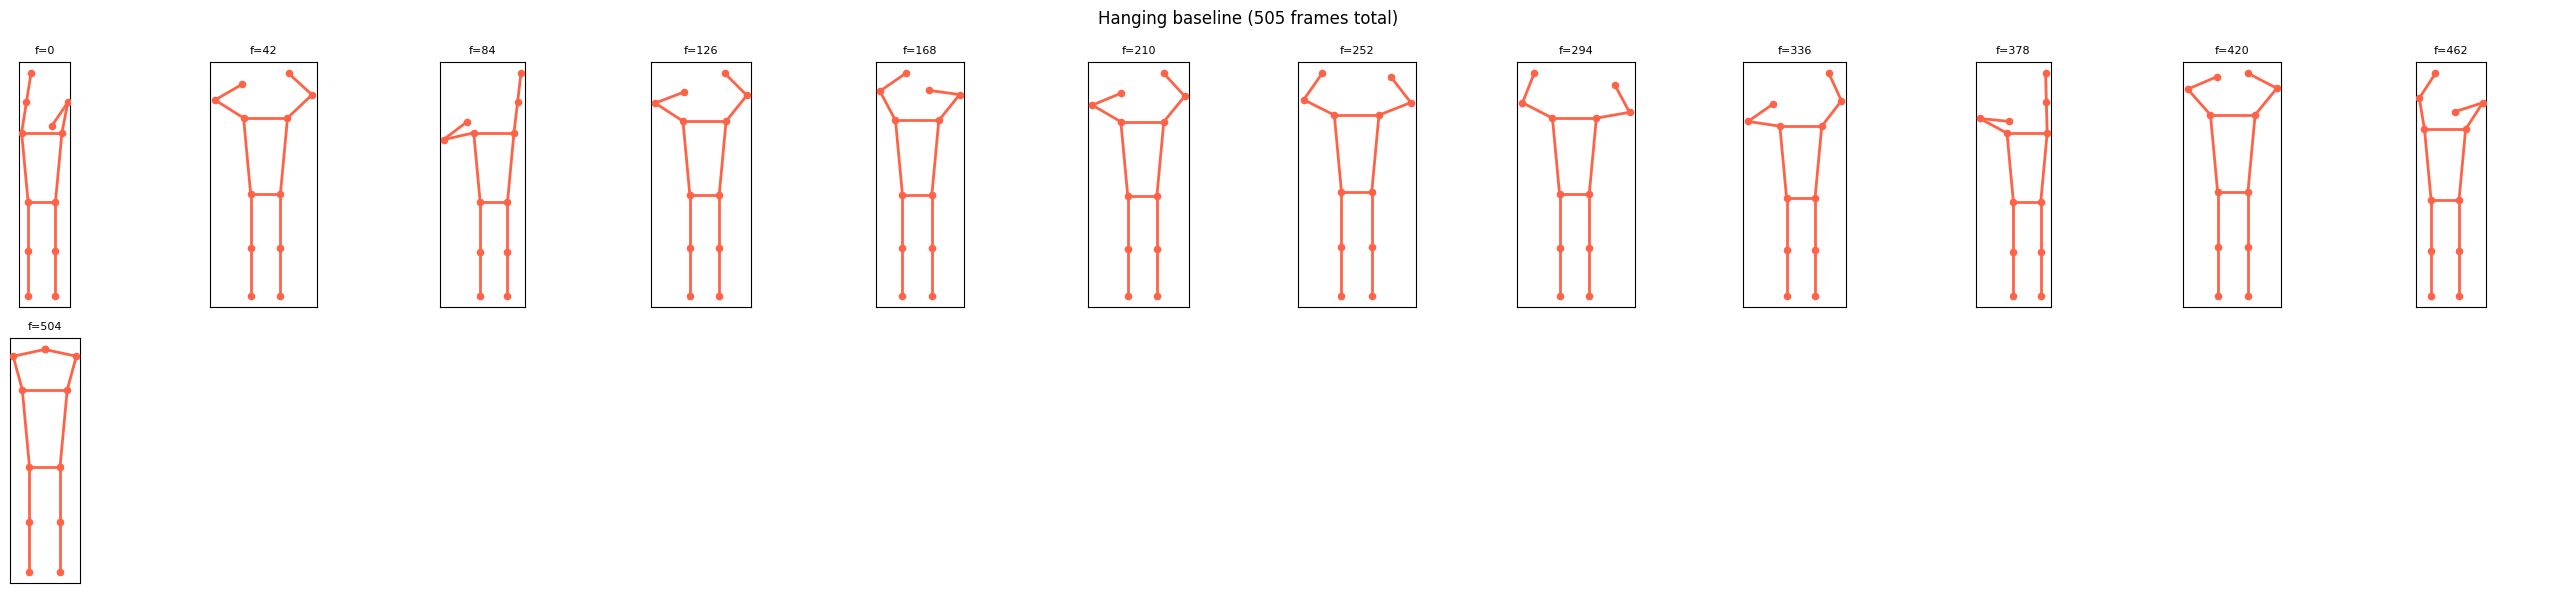

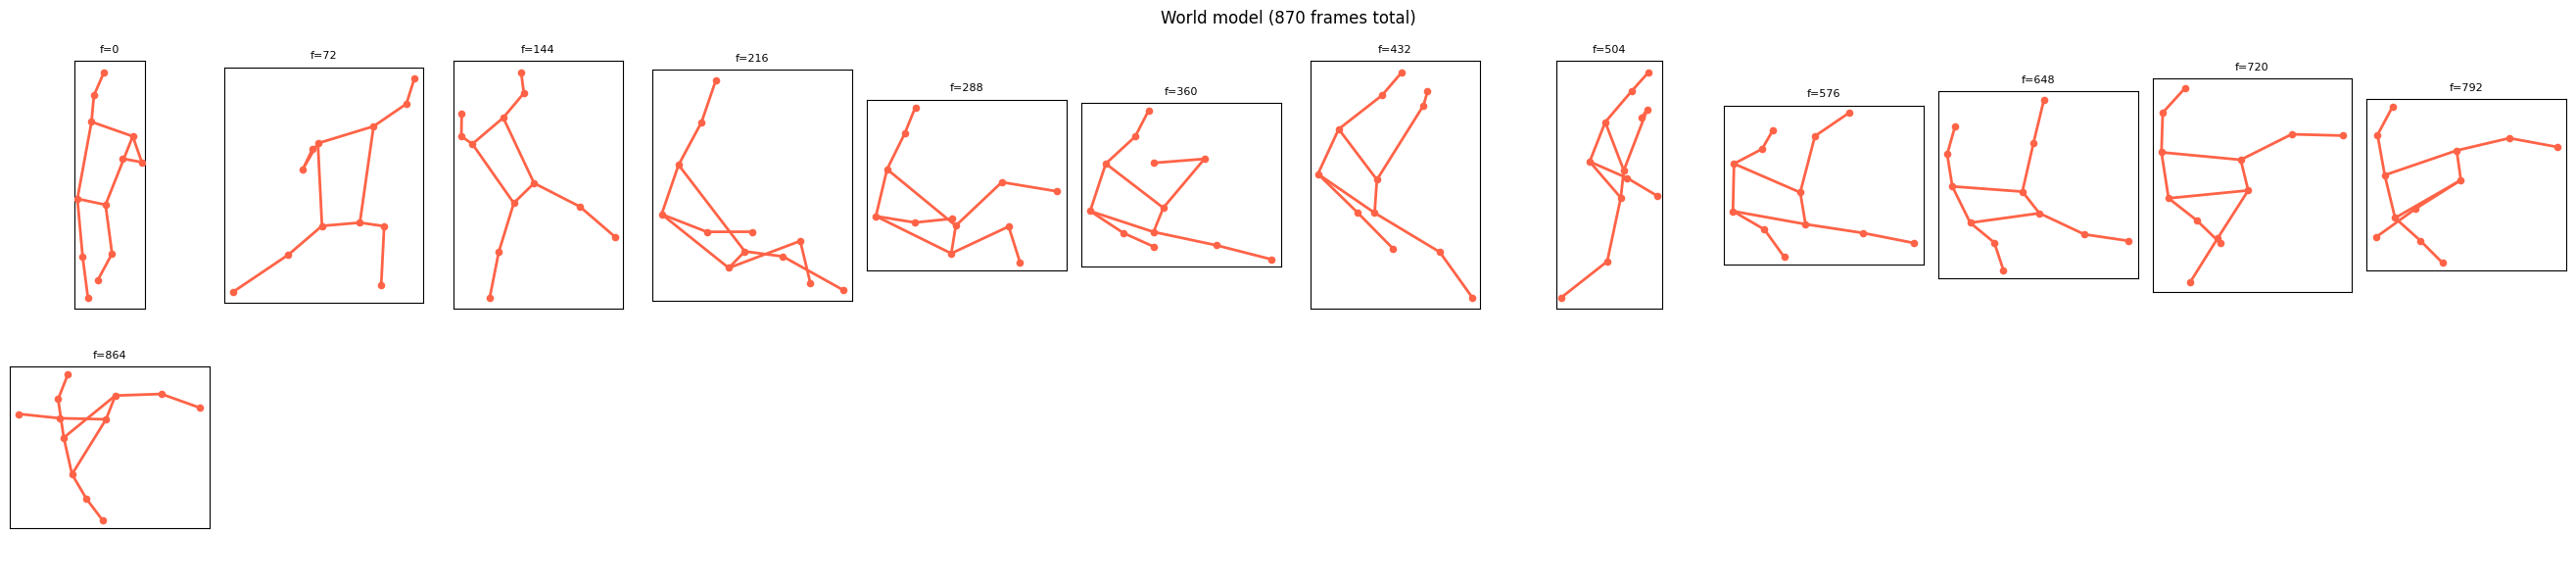

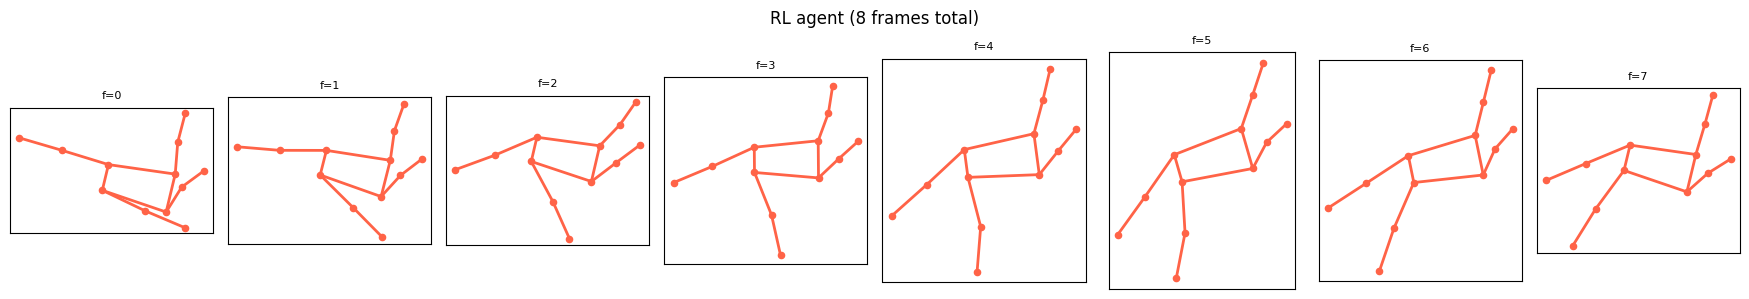

In [5]:
def show_frame_grid(poses, title, every_n=None, max_cols=12):
    """Show evenly-spaced frames from a pose sequence as a skeleton grid."""
    T = len(poses)
    if every_n is None:
        every_n = max(1, T // max_cols)
    frame_idxs = list(range(0, T, every_n))
    n = len(frame_idxs)
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 3 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    for i, fi in enumerate(frame_idxs):
        ax = axes[i // cols, i % cols]
        _draw_skeleton_mpl(ax, poses[fi], color="tomato")
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"f={fi}", fontsize=8)
    # Hide unused
    for i in range(n, rows * cols):
        axes[i // cols, i % cols].axis("off")

    fig.suptitle(f"{title} ({T} frames total)", fontsize=12)
    plt.tight_layout()

show_frame_grid(hanging_poses, "Hanging baseline")
show_frame_grid(wm_poses, "World model")
show_frame_grid(rl_poses, "RL agent")

Saved NN pose comparison to ../data/viz/nn_pose_procrustes.png


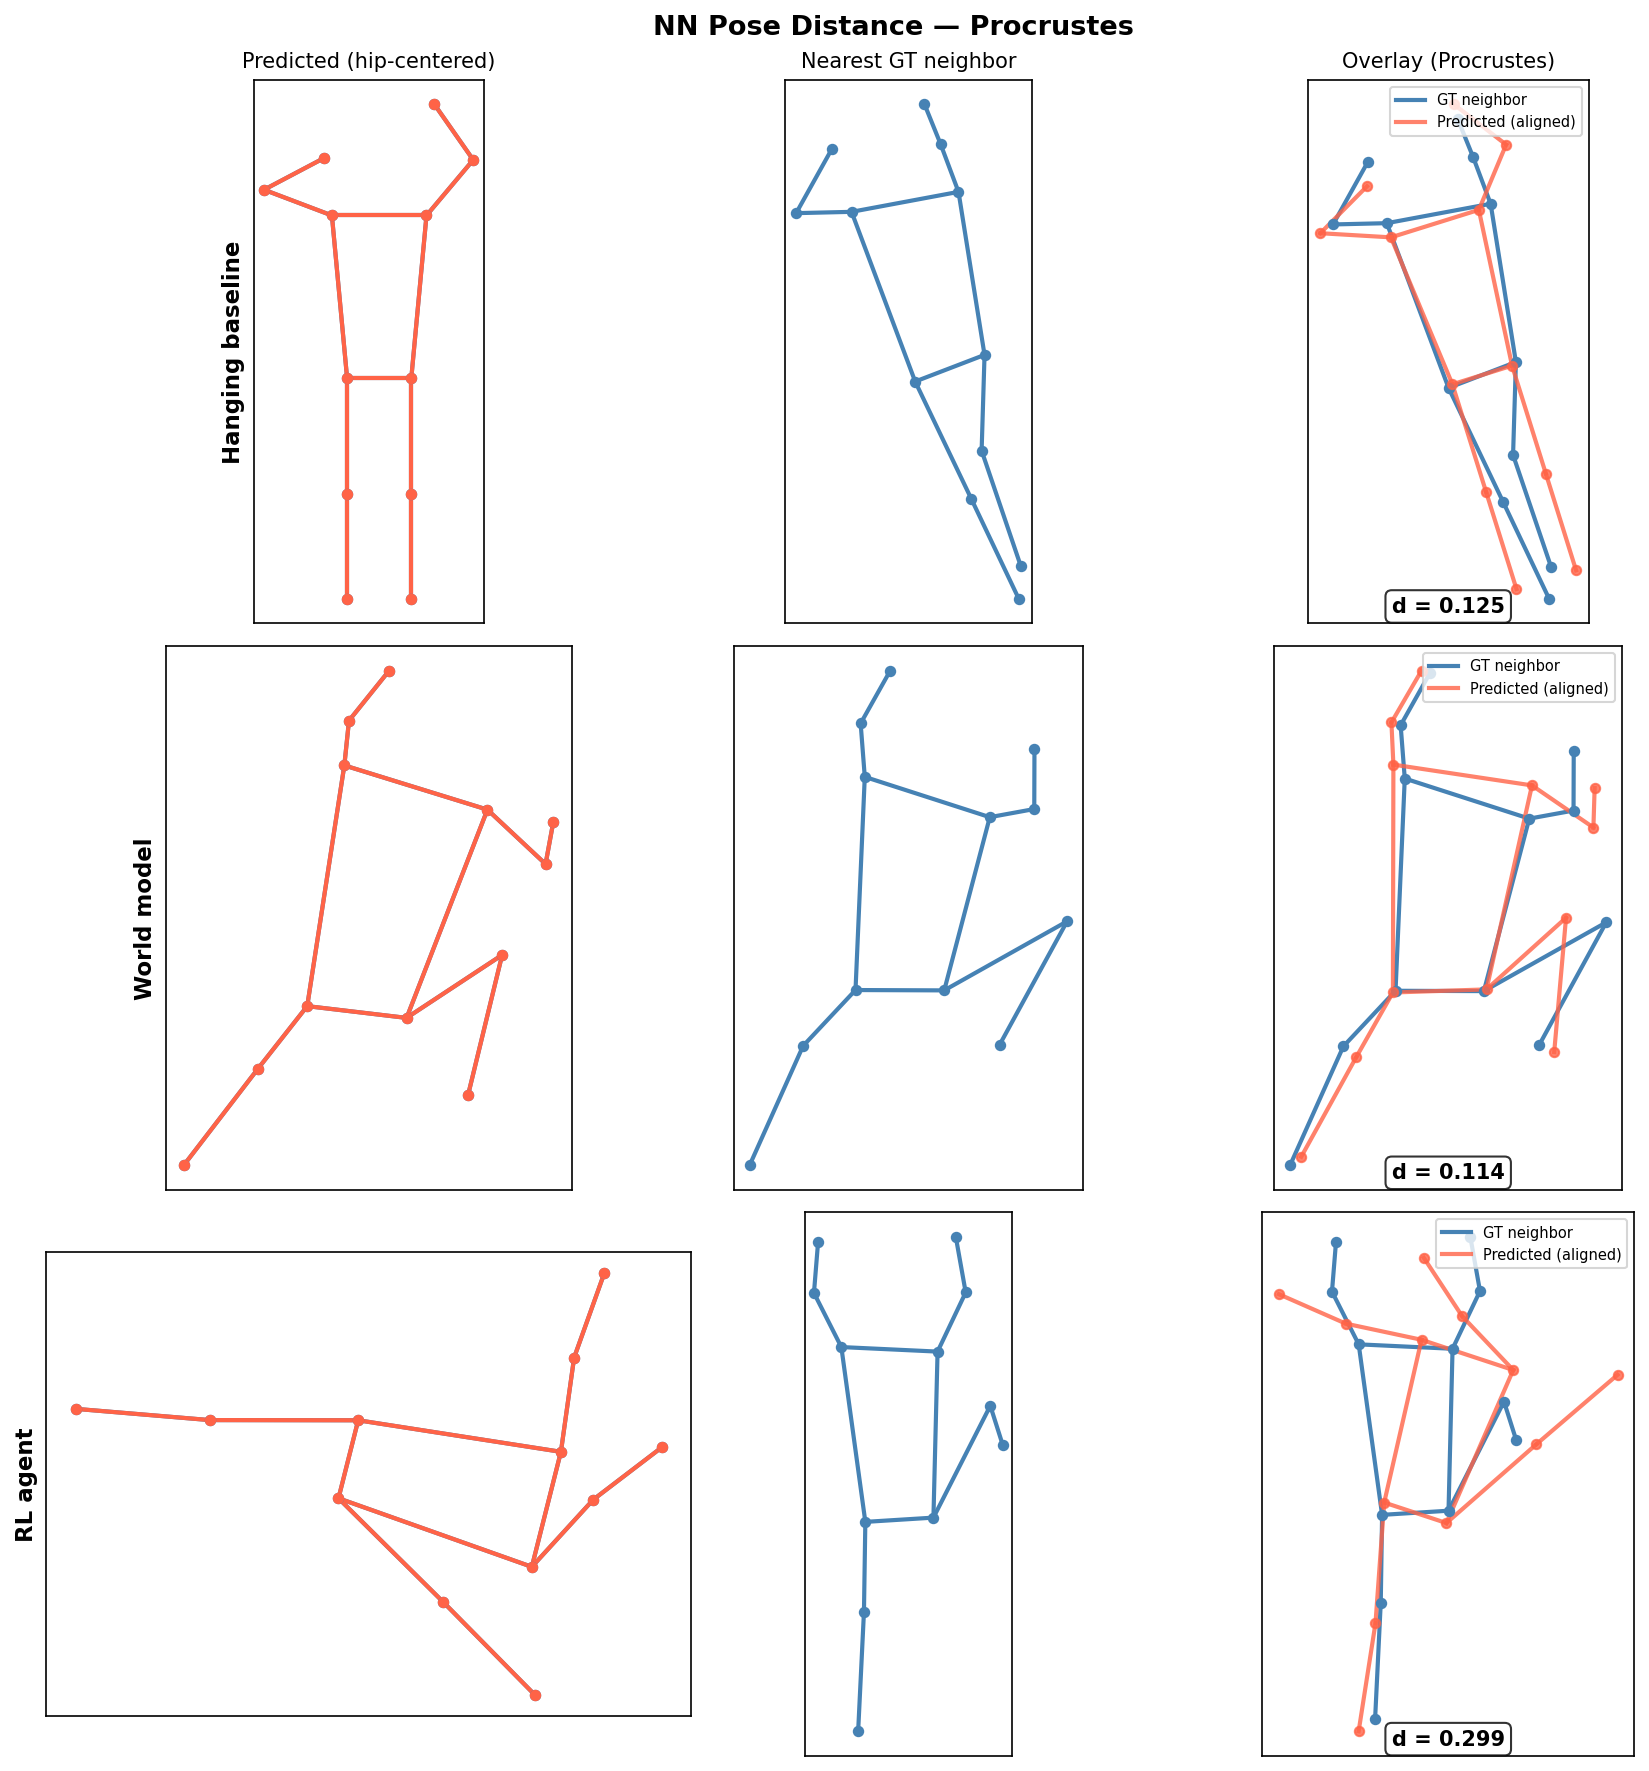

Saved NN pose comparison to ../data/viz/nn_pose_raw.png


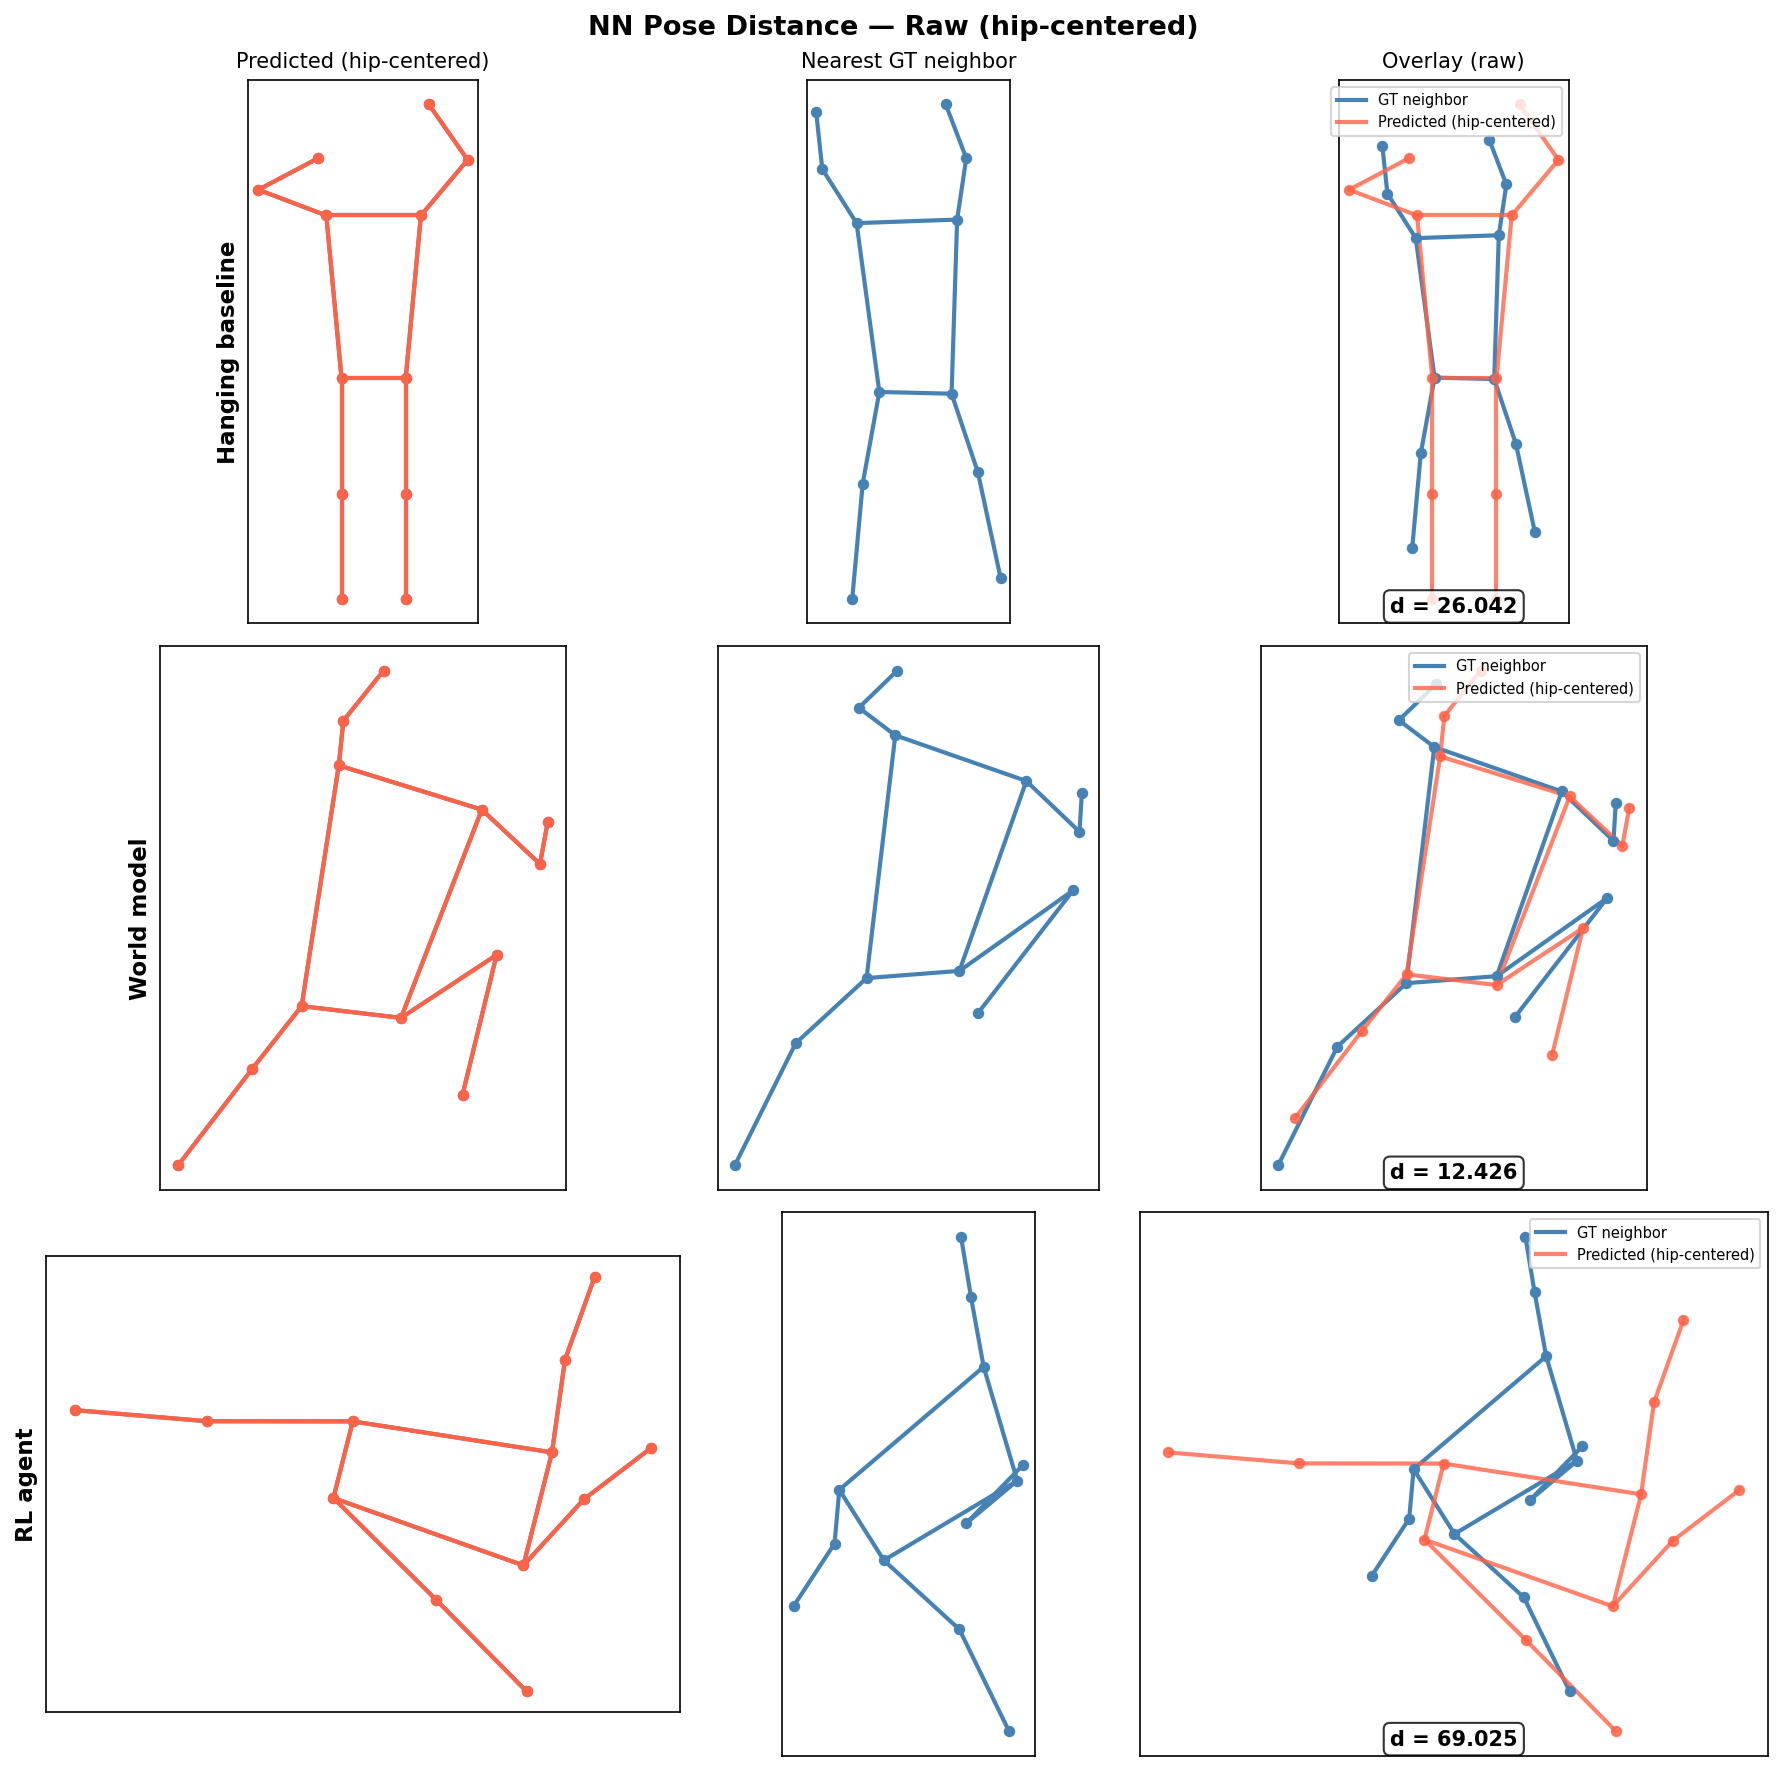

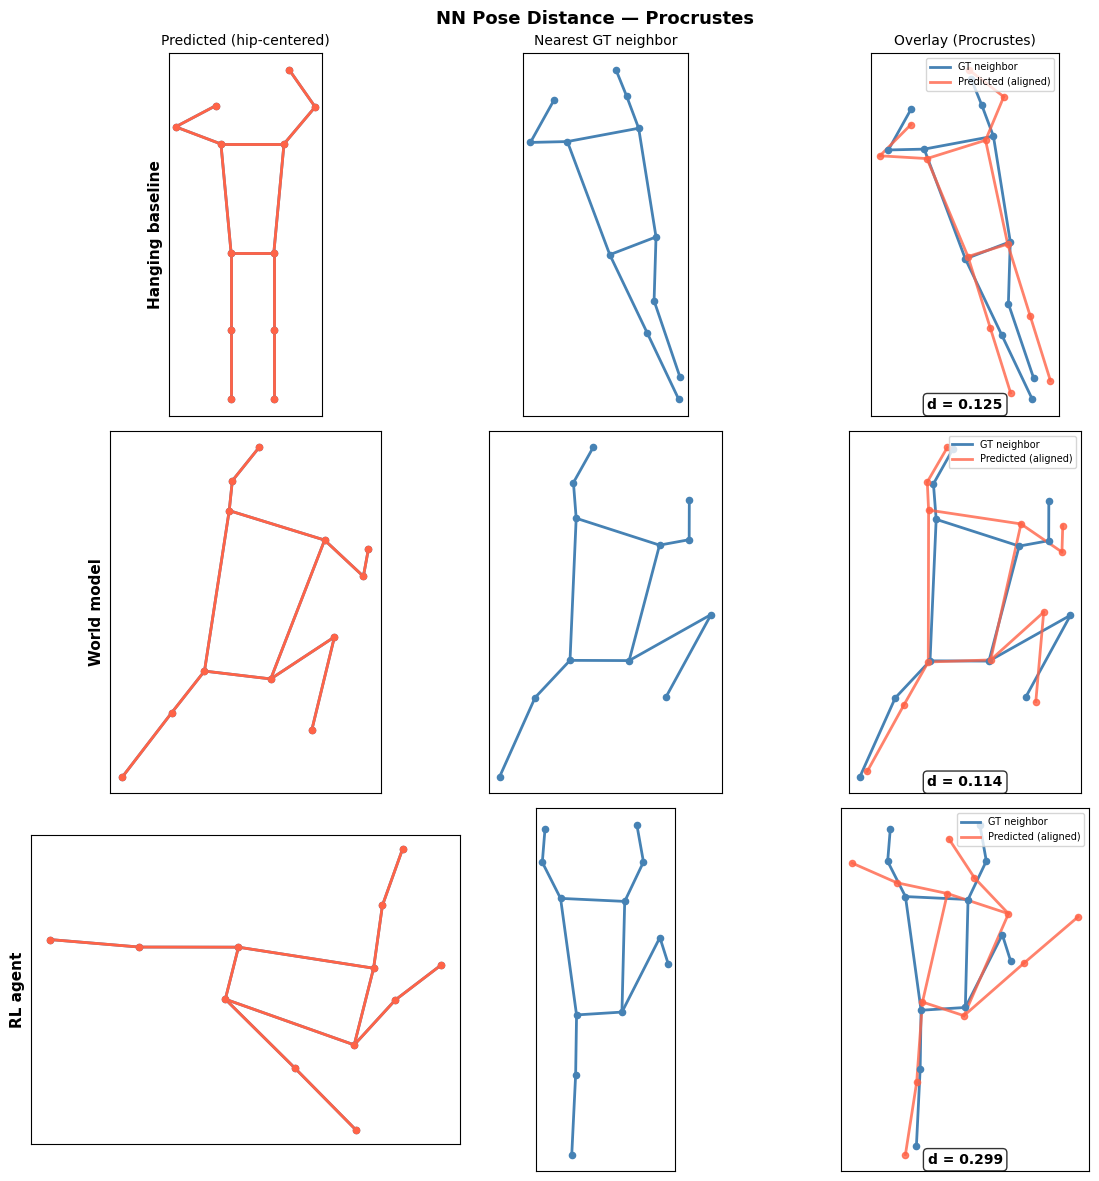

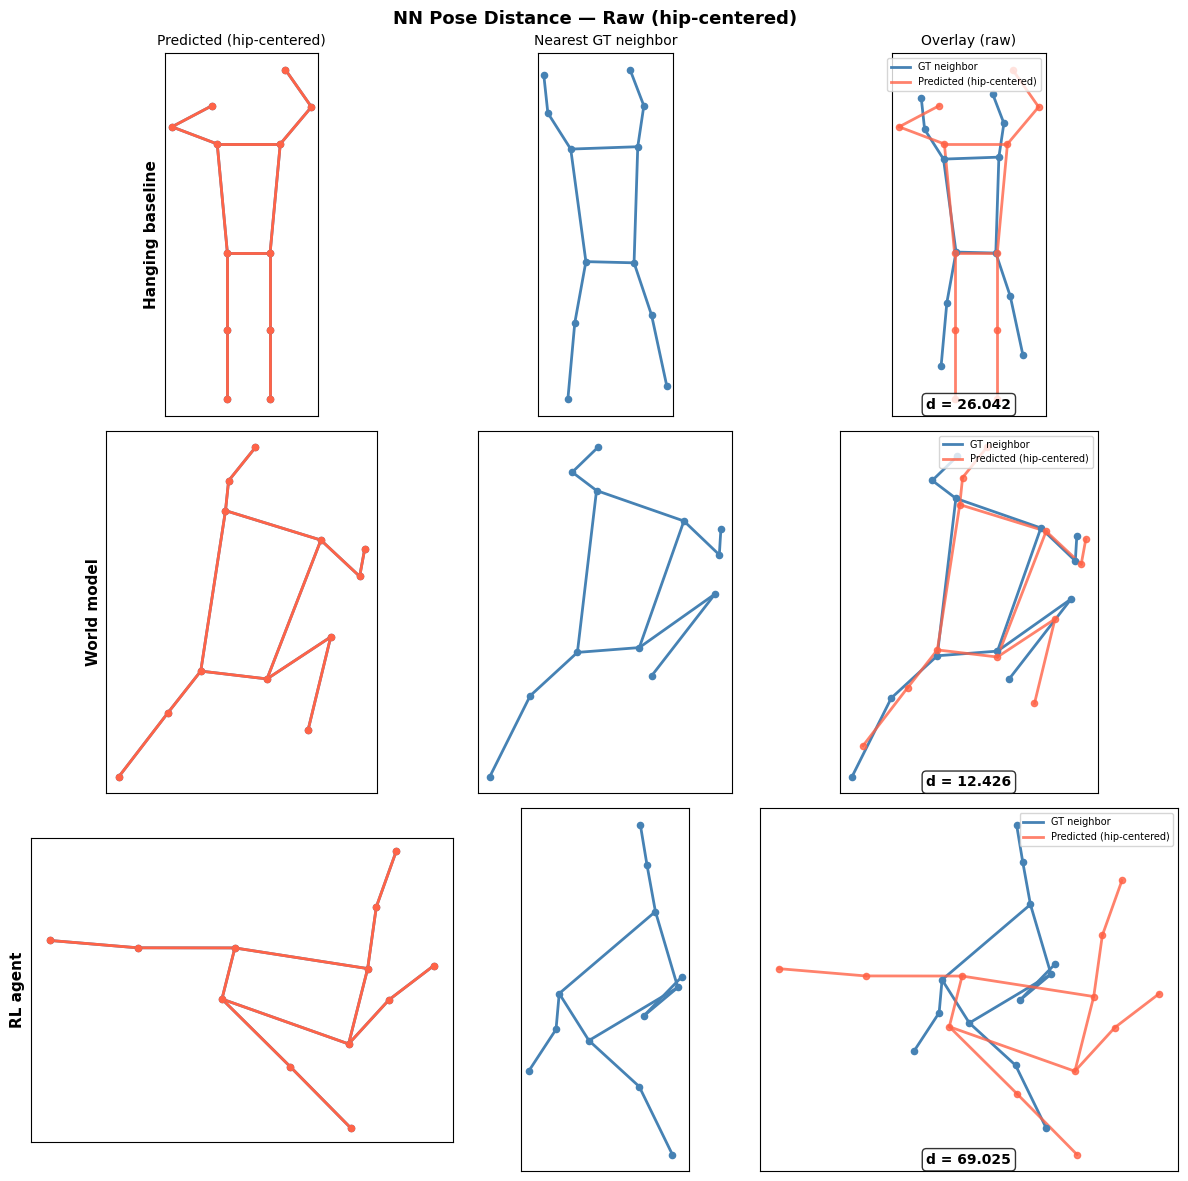

In [6]:
# === PICK FRAME INDICES from the grids above ===
HANGING_FRAME = 50
WM_FRAME = 50
RL_FRAME = 1

method_poses = {
    "Hanging baseline": hanging_poses[HANGING_FRAME],
    "World model": wm_poses[WM_FRAME],
    "RL agent": rl_poses[RL_FRAME],
}

# Sanity check shapes
for name, p in method_poses.items():
    assert p.shape == (config.NUM_CLIMBING_KEYPOINTS, 2), f"{name}: {p.shape}"

fig_proc = plot_nn_pose_comparison(
    method_poses, bank, bank_norm,
    output_path=Path("../data/viz/nn_pose_procrustes.png"),
    alignment="procrustes",
)
display(Image(filename="../data/viz/nn_pose_procrustes.png"))

fig_raw = plot_nn_pose_comparison(
    method_poses, bank, bank_norm,
    output_path=Path("../data/viz/nn_pose_raw.png"),
    alignment="raw",
)
display(Image(filename="../data/viz/nn_pose_raw.png"))

In [7]:
methods = {
    "Hanging baseline": hanging_poses,
    "World model": wm_poses,
    "RL agent": rl_poses,
}

for name, poses in methods.items():
    dists = nearest_neighbor_pose_distance(poses, bank, bank_norm)
    summary = summarize_nn_distances(dists, poses)
    for variant in ("procrustes", "raw"):
        s = summary[variant]
        print(f"{name:20s} [{variant:10s}]  "
              f"wt_mean={s['weighted_mean']:.4f}  "
              f"median={s['median']:.4f}  "
              f"p95={s['p95']:.4f}")
    print()

Hanging baseline     [procrustes]  wt_mean=0.1312  median=0.1311  p95=0.1518
Hanging baseline     [raw       ]  wt_mean=26.3854  median=26.3767  p95=27.5743

World model          [procrustes]  wt_mean=0.4305  median=0.3291  p95=0.5778
World model          [raw       ]  wt_mean=69.1332  median=39.9800  p95=89.5981

RL agent             [procrustes]  wt_mean=0.2182  median=0.2214  p95=0.3061
RL agent             [raw       ]  wt_mean=63.4437  median=64.8305  p95=74.0915

